# 02 — Synthetic Control Method

**Project:** Effects of the North Frontier Economic Free Zone (NFZ) on IMMEX employment

This notebook implements the Synthetic Control Method (Abadie, Diamond & Hainmueller 2010)
for the 10 treated municipalities. For each treated unit it:

1. Builds a **predictor matrix** from pre-treatment characteristics
2. Solves for **donor weights** via a nested V/W optimization
3. Produces the **gap figure** (actual vs synthetic) and the RMSPE ratio

**Outcome choice per municipality.** The primary outcome is `sop` — the share of IMMEX
employment over the total economically active population — which was the main model in the
thesis. Acuña is the exception: its SOP trajectory cannot be matched by any convex combination
of donors (no donor pool unit shares its level and trend), so Acuña uses the log-employment
model, where it fits tightly. This per-unit model selection mirrors the thesis, which likewise
chose the better-fitting model per municipality.

**Method in brief.** For a treated unit, the synthetic control is a weighted average of
donor-pool municipalities chosen to match the treated unit's pre-treatment predictors. Weights
are non-negative and sum to one (no extrapolation). The post-treatment gap between the actual
unit and its synthetic counterpart is the estimated treatment effect.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

PROJECT_ROOT = "/Users/alexvr/GITHUB/nfz_scm_app"
os.chdir(PROJECT_ROOT)

df = pd.read_parquet("data/processed/nfz_panel_clean.parquet")
print("Working directory:", os.getcwd())
print("Panel shape:", df.shape)
df.head()

Working directory: /Users/alexvr/GITHUB/nfz_scm_app
Panel shape: (7175, 44)


,yr,m,date,mun,establishments,est_201912,lp,ap,lpo,apo,...,v24,prod_services_payments,consumed_goods_services_nm,log_immex_emp,log_eap,som,sop,treated,post,treated_post
0,2007,7,2007-07-01,Acuna,47,59,21541.0,2178.0,989,226,...,6682.0,35449.0,66027.0,10.123988,11.226296,67.568153,33.210352,1,0,0
1,2007,8,2007-08-01,Acuna,46,59,22287.0,2163.0,1025,231,...,7957.0,40469.0,64859.0,10.154480,11.221316,69.109582,34.409552,1,0,0
2,2007,9,2007-09-01,Acuna,45,59,22454.0,2068.0,1173,229,...,6232.0,37561.0,63033.0,10.162924,11.216324,69.540492,34.875024,1,0,0
3,2007,10,2007-10-01,Acuna,45,59,22647.0,2150.0,1330,233,...,8094.0,41580.0,54933.0,10.179603,11.211307,70.396582,35.639923,1,0,0
4,2007,11,2007-11-01,Acuna,45,59,21907.0,2121.0,1285,243,...,8288.0,40904.0,62074.0,10.148627,11.206264,68.811761,34.727545,1,0,0


## 1. Configuration

The treatment date is January 2019. Predictors consist of:

- **Point values** of the outcome at evenly spaced pre-treatment dates (every 10 months,
  mirroring the `outcome(570) outcome(580) ... outcome(700)` point predictors in the Stata
  `allsynth` specification)
- **Pre-period averages** of the outcome and the other economic variables, all standardized
  before entering the optimizer (equivalent to Stata's `transform(..., normalize)`)

In [2]:
treatment_date = pd.Timestamp("2019-01-01")
pre_start = pd.Timestamp("2007-07-01")

# Point-predictor dates: every 10 months across the pre-treatment window
point_dates = pd.date_range(start=pre_start, end="2018-10-01", freq="10MS")

# Variables entering the predictor matrix as pre-period averages
avg_vars = [
    "log_immex_emp", "som", "sop",
    "total_work_hours", "establishments",
    "worked_days_manuf", "income_national",
    "income_international", "prod_services_payments",
    "consumed_goods_services_nm"
]

# The 10 treated municipalities (NFZ)
treated_muns = [
    "Acuna", "Ensenada", "Juarez", "Matamoros", "Mexicali",
    "Nogales", "Nuevo Laredo", "Reynosa", "Tecate", "Tijuana"
]

# Outcome model per municipality: SOP for all except Acuña (see header note)
outcome_for = {mun: "sop" for mun in treated_muns}
outcome_for["Acuna"] = "log_immex_emp"

print(f"{len(point_dates)} point-predictor dates")
print(f"{len(avg_vars)} averaged predictors")

14 point-predictor dates
10 averaged predictors


## 2. Predictor-matrix builder

For a given treated unit, this constructs:

- `X1` — the treated unit's standardized predictor vector
- `X0` — the donor pool's standardized predictor matrix
- `donor_muns` — the donor names (column order of `X0`)

The donor pool excludes **all** treated municipalities, so each synthetic control is built only
from untreated units (no other NFZ municipality can leak into the counterfactual).

In [3]:
def build_predictor_matrix(df, treated_unit, treatment_date, point_dates,
                           avg_vars, outcome="sop"):
    """Build standardized predictor matrices X1 (treated) and X0 (donors)."""
    pre_df = df[df["date"] < treatment_date].copy()

    # Donor pool = every municipality that is NOT treated
    all_treated = df[df["treated"] == 1]["mun"].unique()
    donor_muns = [m for m in df["mun"].unique() if m not in all_treated]

    all_units = [treated_unit] + donor_muns
    predictors = {}

    for unit in all_units:
        unit_pre = pre_df[pre_df["mun"] == unit].set_index("date").sort_index()
        vals = []

        # Point values of the outcome at the chosen dates
        for d in point_dates:
            vals.append(unit_pre.loc[d, outcome] if d in unit_pre.index else np.nan)

        # Pre-period averages of all predictor variables
        for var in avg_vars:
            vals.append(unit_pre[var].mean() if var in unit_pre.columns else np.nan)

        predictors[unit] = vals

    pred_matrix = pd.DataFrame(predictors).values  # (n_predictors, n_units)

    # Standardize each predictor row across units (Stata's normalize option)
    row_means = np.nanmean(pred_matrix, axis=1, keepdims=True)
    row_stds = np.nanstd(pred_matrix, axis=1, keepdims=True)
    row_stds[row_stds == 0] = 1
    pred_norm = (pred_matrix - row_means) / row_stds

    X1 = pred_norm[:, 0]
    X0 = pred_norm[:, 1:]
    return X1, X0, donor_muns

## 3. The optimizer

SCM is a nested optimization (Abadie 2010):

- **Inner loop** — given a diagonal predictor-weight matrix `V`, find donor weights `W` that
  minimize the V-weighted predictor distance, subject to `sum(W)=1` and `W >= 0`.
- **Outer loop** — find the `V` that minimizes the **pre-treatment outcome fit**. Better
  predictor weights produce a synthetic control that tracks the treated unit more tightly
  before treatment.

The outer loop uses Nelder-Mead with **5 random restarts** to avoid poor local optima — the
fit quality depends meaningfully on this. The full 10-municipality run takes roughly 30-40
minutes; this is a one-time cost, results are stored and saved.

In [4]:
def solve_weights_given_V(X1, X0, V):
    """Inner optimization: donor weights W minimizing (X1 - X0 w)' V (X1 - X0 w)."""
    n_donors = X0.shape[1]

    def loss(w):
        diff = X1 - X0 @ w
        return float(diff @ V @ diff)

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n_donors
    w0 = np.ones(n_donors) / n_donors

    res = minimize(loss, w0, method="SLSQP", bounds=bounds,
                   constraints=constraints,
                   options={"maxiter": 20000, "ftol": 1e-12})
    return res.x


def solve_scm(df, treated_unit, treatment_date, point_dates, avg_vars, outcome="sop"):
    """Full SCM with nested V/W optimization. Returns (weights, V_diagonal)."""
    X1, X0, donor_muns = build_predictor_matrix(
        df, treated_unit, treatment_date, point_dates, avg_vars, outcome=outcome
    )
    n_preds = X1.shape[0]

    # Pre-treatment outcome series, used to score V in the outer loop
    pre_df = df[df["date"] < treatment_date]
    Y1_pre = (pre_df[pre_df["mun"] == treated_unit]
              .set_index("date")[outcome].sort_index().values)
    Y0_pre = (pre_df[pre_df["mun"].isin(donor_muns)]
              .pivot(index="date", columns="mun", values=outcome)
              .sort_index()[donor_muns].values)

    def outer_loss(v_raw):
        # Sigmoid keeps the diagonal of V in (0, 1); clip guards against overflow
        v = 1.0 / (1.0 + np.exp(-np.clip(v_raw, -30, 30)))
        w = solve_weights_given_V(X1, X0, np.diag(v))
        resid = Y1_pre - Y0_pre @ w
        return float(resid @ resid)

    # Multiple restarts to avoid poor local optima; keep the best V found
    best_loss = np.inf
    best_v_raw = None
    rng = np.random.default_rng(42)

    starting_points = [np.zeros(n_preds)] + [rng.normal(0, 1, n_preds) for _ in range(4)]

    for v0 in starting_points:
        res_outer = minimize(outer_loss, v0, method="Nelder-Mead",
                             options={"maxiter": 3000, "xatol": 1e-6, "fatol": 1e-6})
        if res_outer.fun < best_loss:
            best_loss = res_outer.fun
            best_v_raw = res_outer.x

    v_final = 1.0 / (1.0 + np.exp(-np.clip(best_v_raw, -30, 30)))
    w_final = solve_weights_given_V(X1, X0, np.diag(v_final))
    return pd.Series(w_final, index=donor_muns), v_final

## 4. Gap computation and plotting

`compute_gap` builds the actual and synthetic series over the full period and returns the gap.
`plot_gap` draws the classic two-panel SCM figure and reports the RMSPE ratio
(post-treatment fit error ÷ pre-treatment fit error). A larger ratio means the post-treatment
divergence is large relative to how well the synthetic tracked the unit beforehand.

In [5]:
def compute_gap(df, treated_unit, weights, outcome="sop"):
    """Return actual, synthetic, and gap series over the full period."""
    donor_muns = weights.index.tolist()

    actual = (df[df["mun"] == treated_unit]
              .set_index("date")[outcome].sort_index())

    Y0_full = (df[df["mun"].isin(donor_muns)]
               .pivot(index="date", columns="mun", values=outcome)
               .sort_index()[donor_muns])
    Y0_full = Y0_full.loc[actual.index]

    synthetic = pd.Series(Y0_full.values @ weights.values,
                          index=actual.index, name="synthetic")
    gap = actual - synthetic
    return actual, synthetic, gap


def plot_gap(actual, synthetic, gap, treated_unit, outcome="sop", ax_title=None):
    """Two-panel SCM gap figure. Returns (pre_rmspe, post_rmspe, ratio)."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(actual.index, actual.values, color="black", linewidth=1.8,
             label=f"{treated_unit} (actual)")
    ax1.plot(synthetic.index, synthetic.values, color="steelblue",
             linewidth=1.5, linestyle="--", label="Synthetic")
    ax1.axvline(treatment_date, color="red", linestyle="--", linewidth=1.2,
                label="Treatment (Jan 2019)")
    ax1.set_ylabel(outcome)
    ax1.set_title(ax_title or f"Synthetic Control — {treated_unit}")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2.plot(gap.index, gap.values, color="darkred", linewidth=1.5)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.axvline(treatment_date, color="red", linestyle="--", linewidth=1.2)
    ax2.fill_between(gap.index, gap.values, 0,
                     where=(gap.index >= treatment_date),
                     alpha=0.2, color="darkred", label="Treatment effect")
    ax2.set_ylabel("Gap (Actual − Synthetic)")
    ax2.set_xlabel("Date")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    pre_gap = gap[gap.index < treatment_date]
    post_gap = gap[gap.index >= treatment_date]
    pre_rmspe = np.sqrt(np.mean(pre_gap.values ** 2))
    post_rmspe = np.sqrt(np.mean(post_gap.values ** 2))
    ratio = post_rmspe / pre_rmspe

    fig.text(0.13, 0.01,
             f"Pre-RMSPE: {pre_rmspe:.4f}  |  Post-RMSPE: {post_rmspe:.4f}  |  Ratio: {ratio:.2f}",
             fontsize=9, color="gray")
    plt.tight_layout()
    plt.show()
    return pre_rmspe, post_rmspe, ratio

## 5. Run all 10 treated municipalities

Each unit uses its designated outcome model (`outcome_for`, defined in section 1). Runs take
from under a minute to several minutes per unit — the anomalous units (Juárez, Reynosa,
Tijuana) are slower to fit. The full loop takes roughly 30-40 minutes; results are stored in
the `results` dictionary and the summary is saved to CSV at the end.

Running SCM for Acuna (log_immex_emp)...


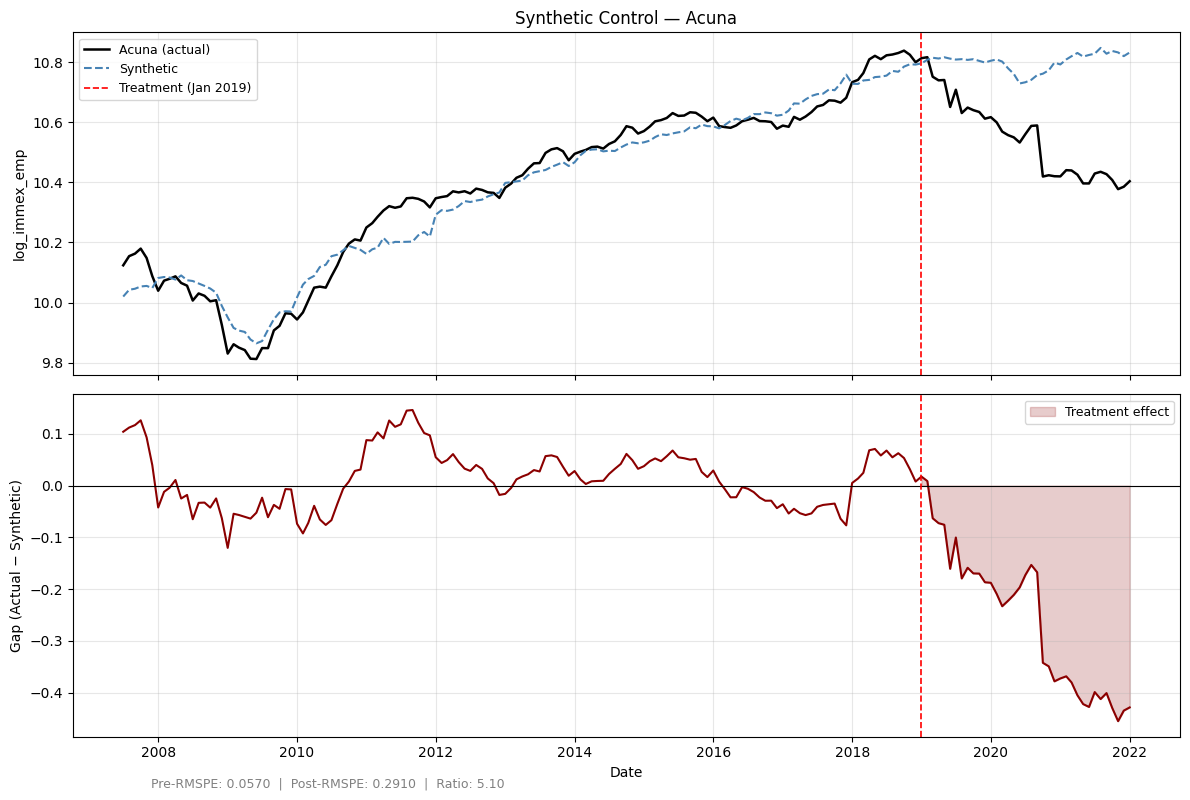

  Done. RMSPE ratio: 5.10

Running SCM for Ensenada (sop)...


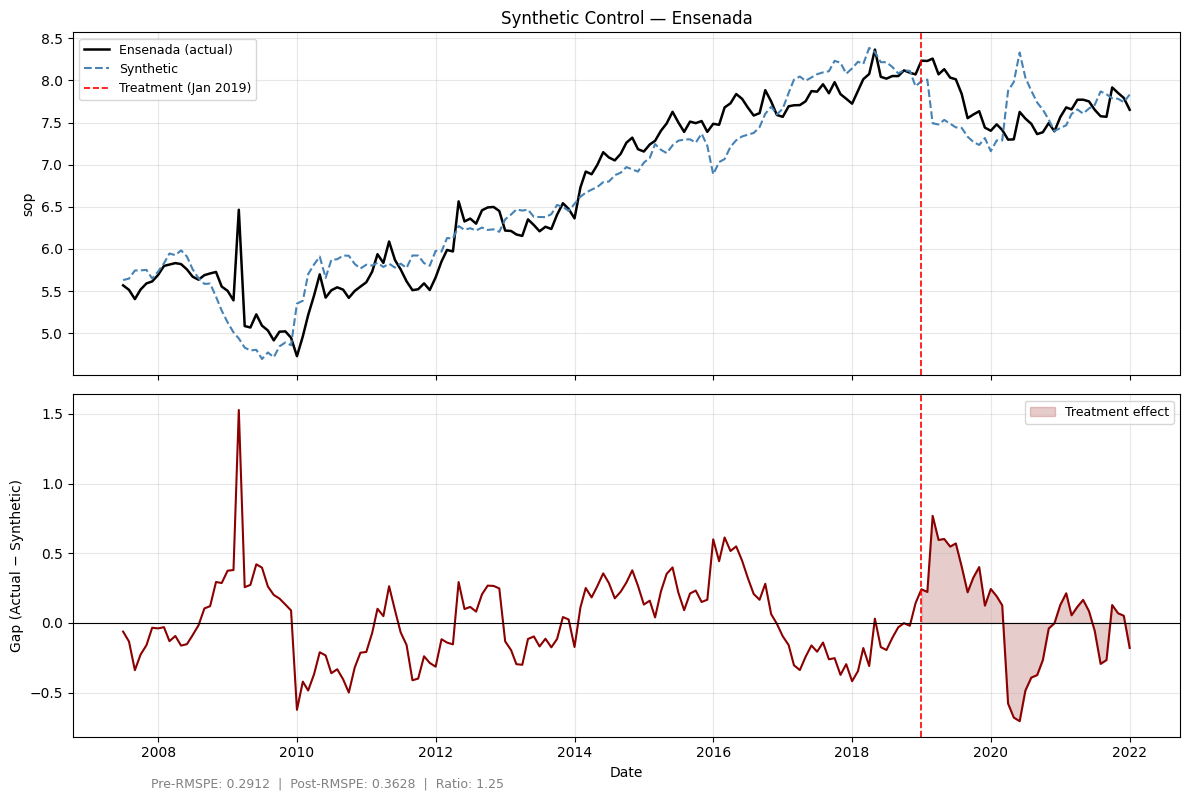

  Done. RMSPE ratio: 1.25

Running SCM for Juarez (sop)...


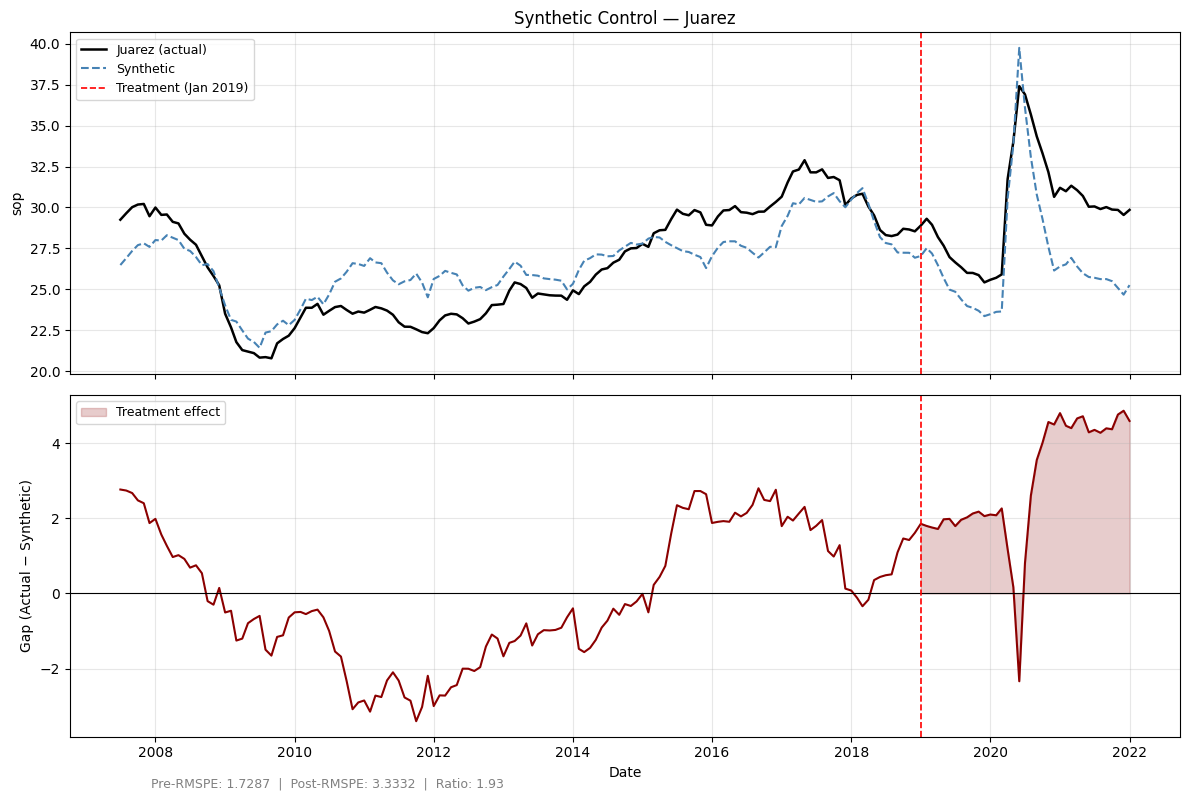

  Done. RMSPE ratio: 1.93

Running SCM for Matamoros (sop)...


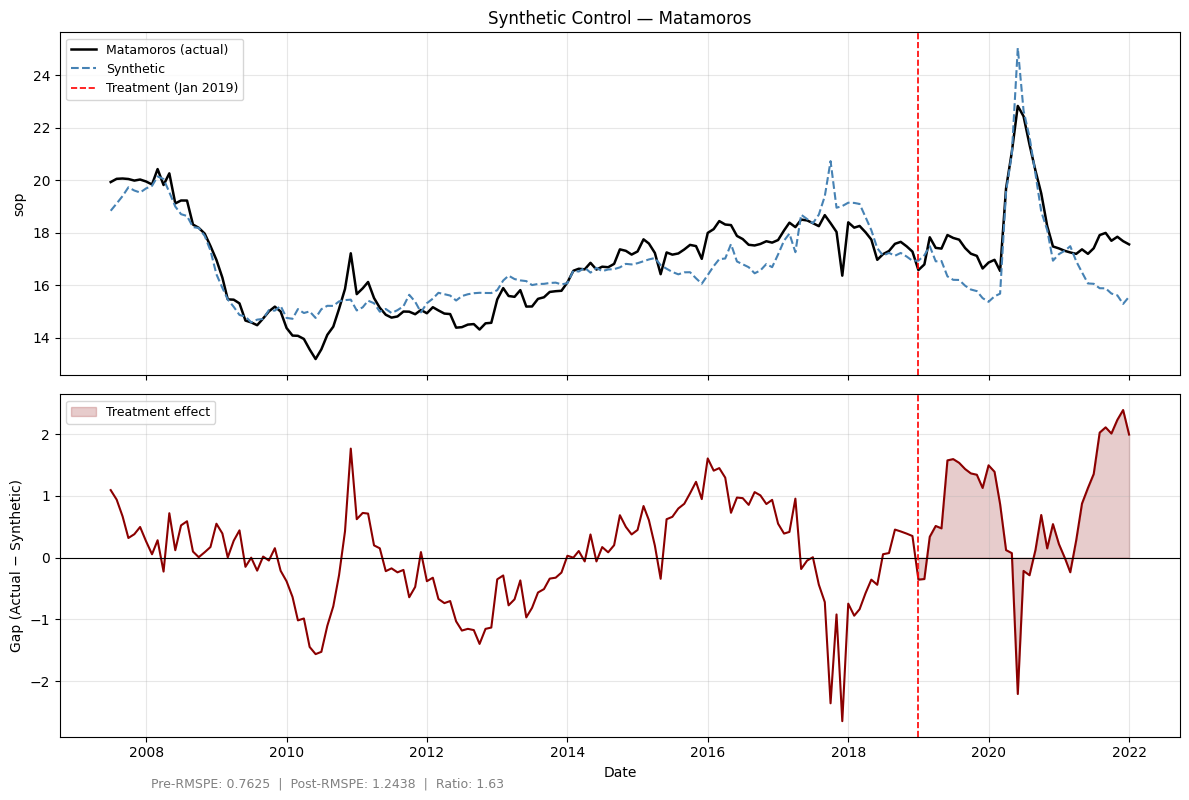

  Done. RMSPE ratio: 1.63

Running SCM for Mexicali (sop)...


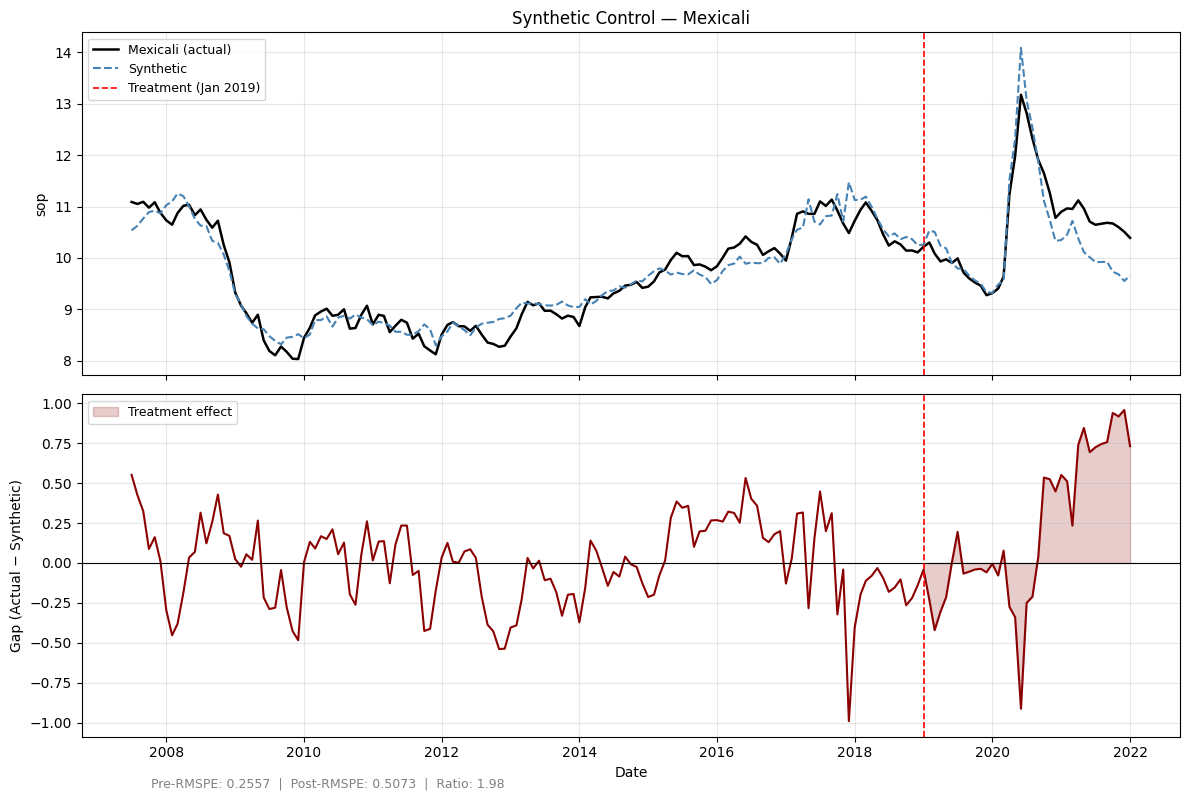

  Done. RMSPE ratio: 1.98

Running SCM for Nogales (sop)...


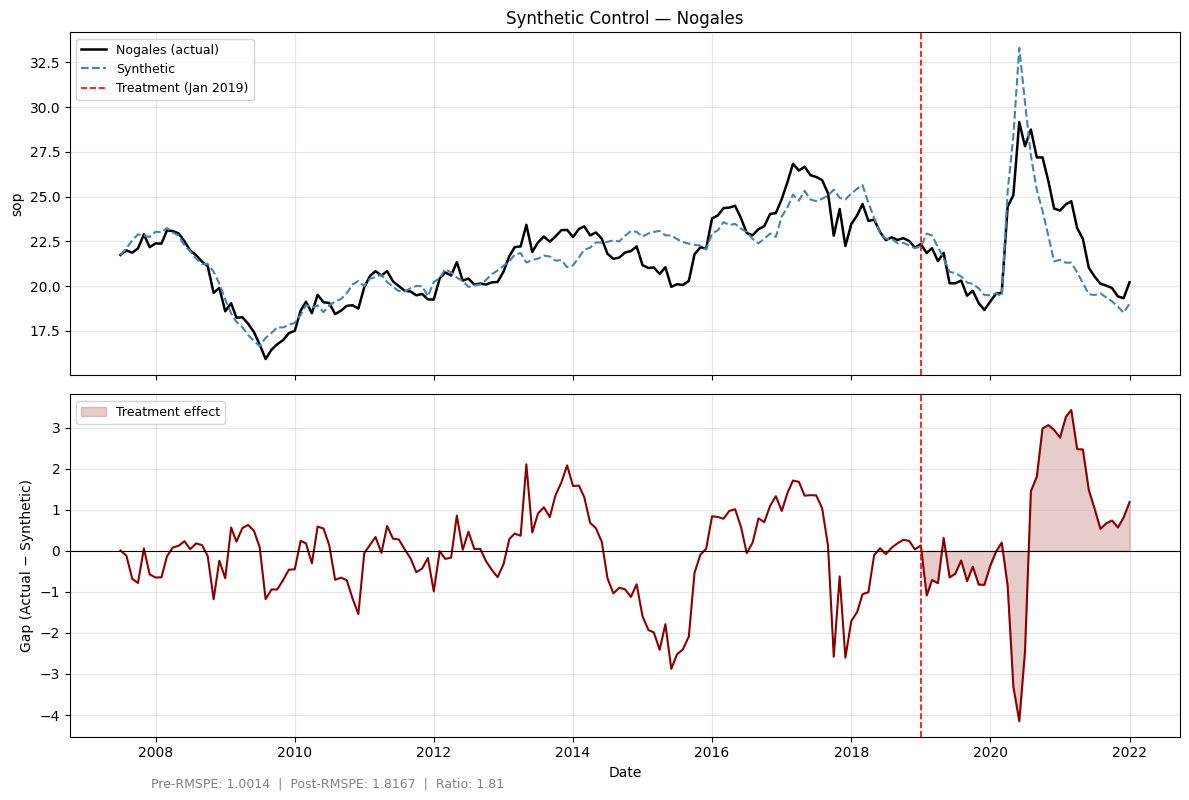

  Done. RMSPE ratio: 1.81

Running SCM for Nuevo Laredo (sop)...


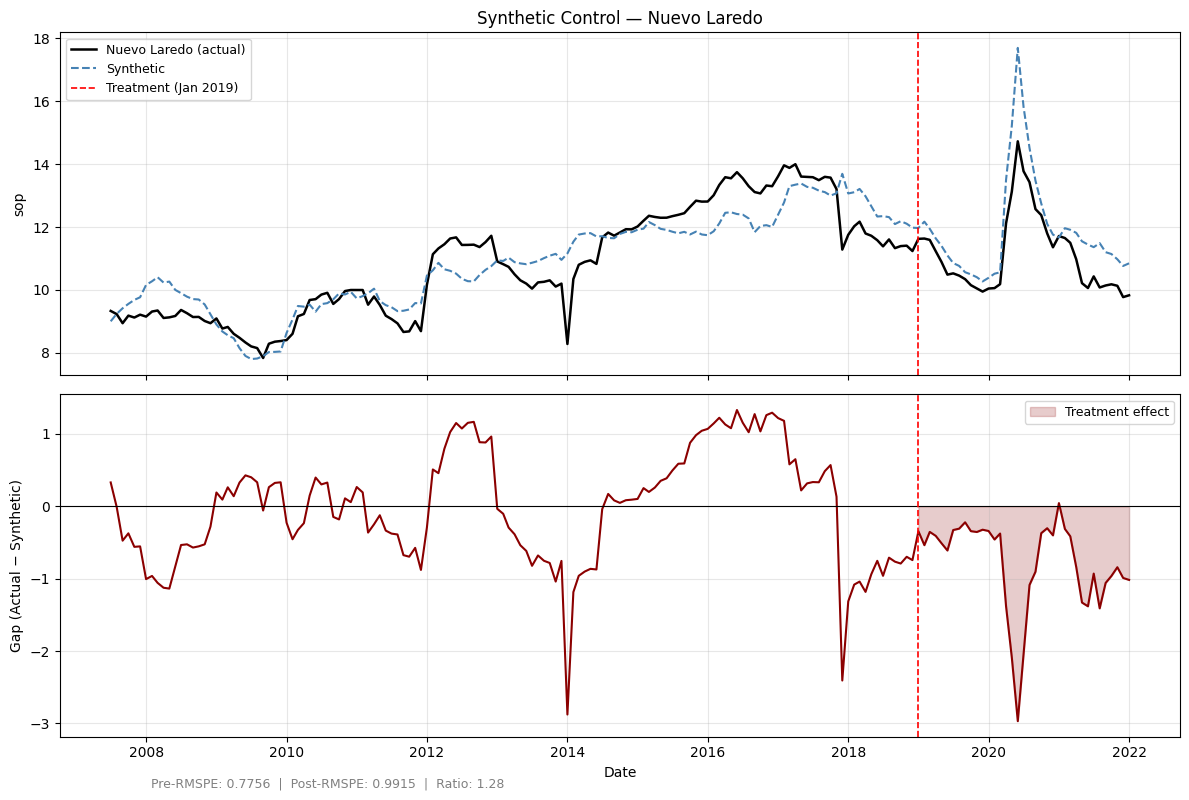

  Done. RMSPE ratio: 1.28

Running SCM for Reynosa (sop)...


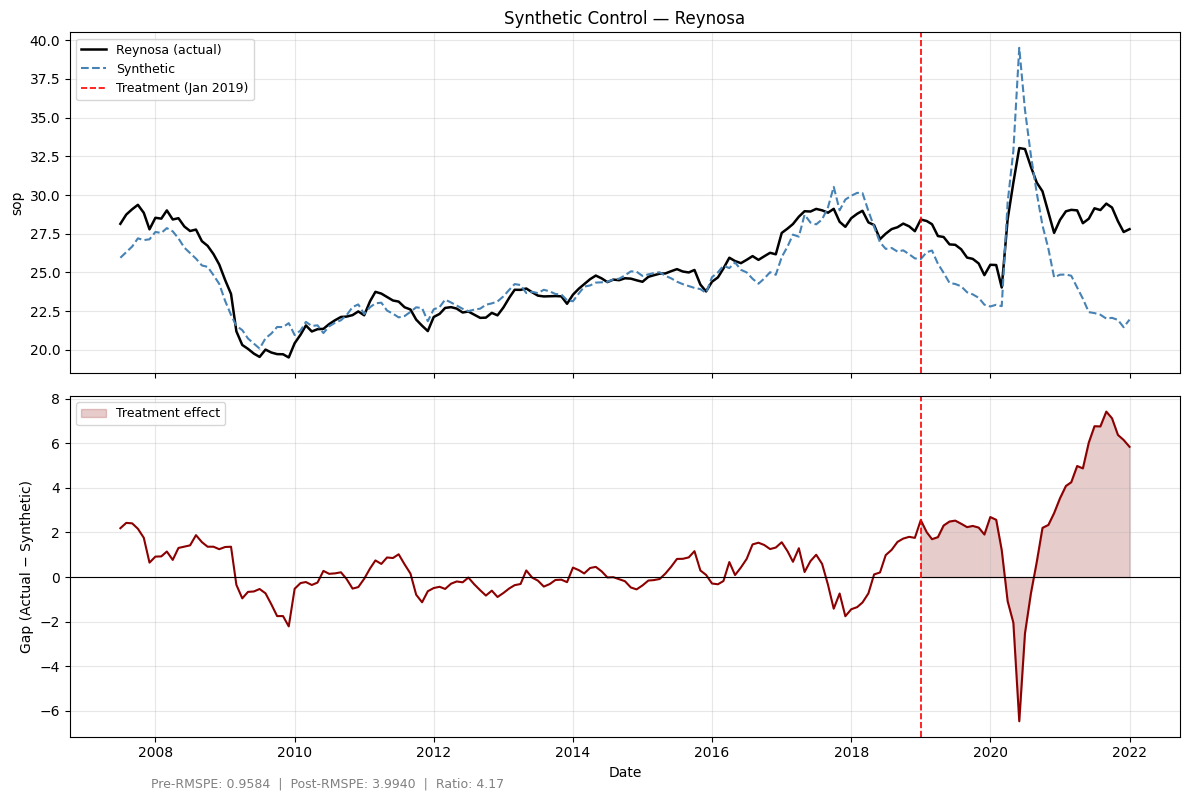

  Done. RMSPE ratio: 4.17

Running SCM for Tecate (sop)...


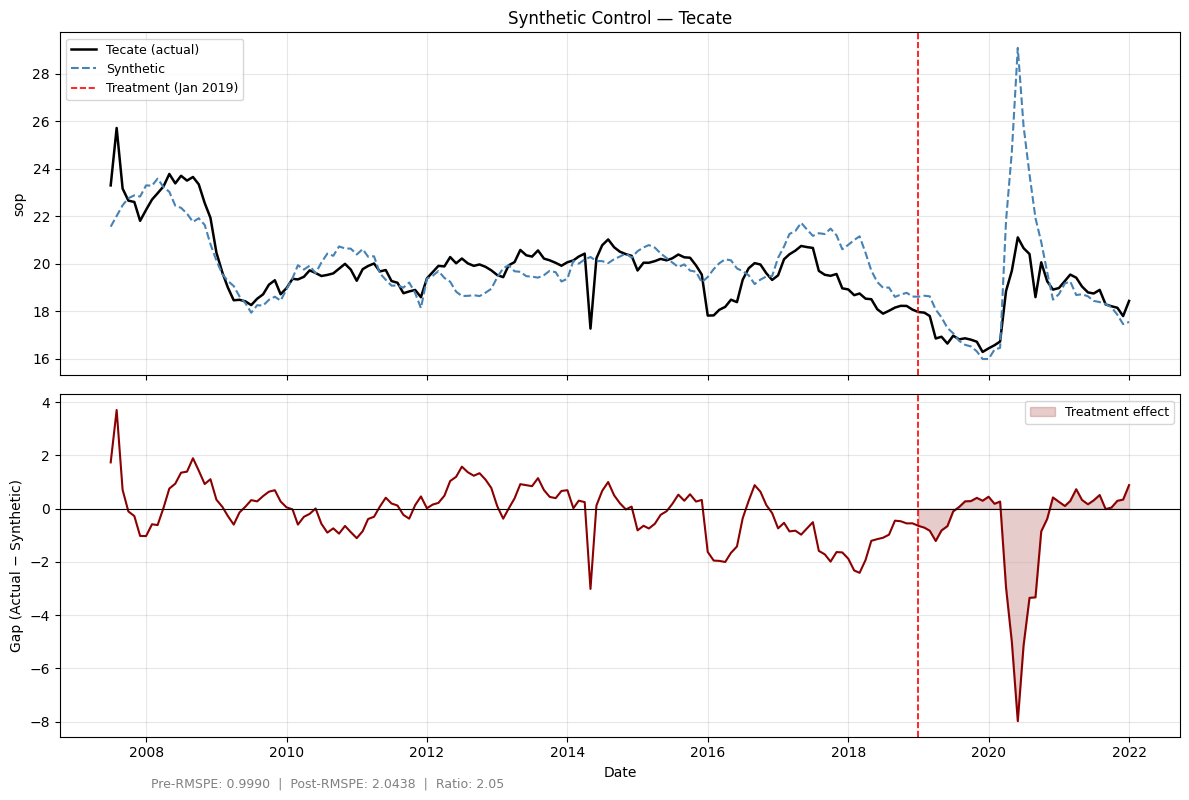

  Done. RMSPE ratio: 2.05

Running SCM for Tijuana (sop)...


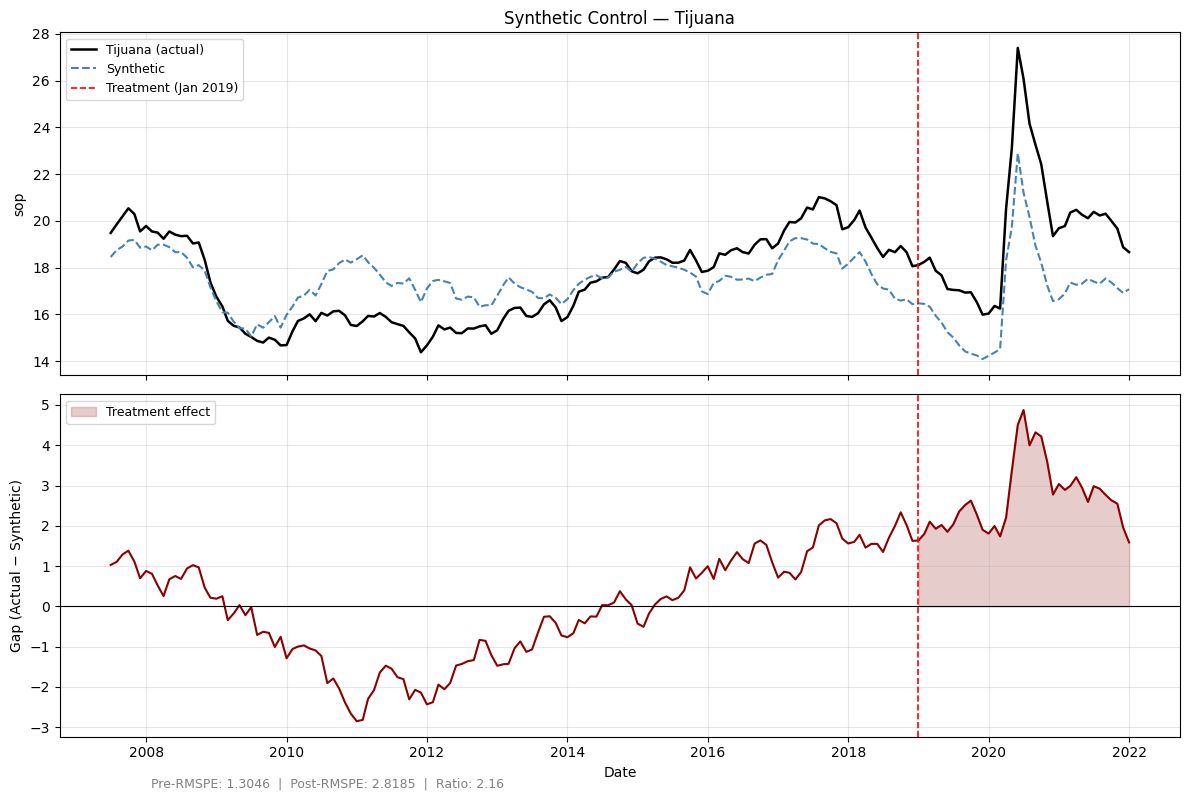

  Done. RMSPE ratio: 2.16

All municipalities done.


In [6]:
results = {}

for mun in treated_muns:
    outcome = outcome_for[mun]
    print(f"Running SCM for {mun} ({outcome})...")
    try:
        weights, v = solve_scm(df, mun, treatment_date, point_dates,
                               avg_vars, outcome=outcome)
        actual, synthetic, gap = compute_gap(df, mun, weights, outcome=outcome)
        pre_rmspe, post_rmspe, ratio = plot_gap(
            actual, synthetic, gap, mun, outcome=outcome
        )
        results[mun] = {
            "weights": weights, "actual": actual, "synthetic": synthetic,
            "gap": gap, "pre_rmspe": pre_rmspe,
            "post_rmspe": post_rmspe, "ratio": ratio,
            "outcome": outcome
        }
        print(f"  Done. RMSPE ratio: {ratio:.2f}\n")
    except Exception as e:
        print(f"  ERROR for {mun}: {e}\n")

print("All municipalities done.")

## 6. Summary table

All four fit/effect statistics per municipality, sorted by RMSPE ratio (strongest signals
first). The sign of the mean post-treatment gap gives the direction of the estimated effect;
the ratio is the inference measure (post-treatment divergence relative to pre-treatment noise).

**Interpretation guide:** ratios near 1 indicate a null effect; ratios above ~2 indicate a
meaningful divergence. Note that post-2020 gaps partly reflect the COVID-19 shock, so
ratios should be read alongside the gap figures (e.g. Tecate's ratio is inflated by a
short-lived 2020 spike rather than a sustained policy effect).

In [7]:
summary_rows = []
for mun, r in results.items():
    post_gap = r["gap"][r["gap"].index >= treatment_date]
    summary_rows.append({
        "Municipality": mun,
        "Model": r["outcome"],
        "Pre-RMSPE": round(r["pre_rmspe"], 4),
        "Post-RMSPE": round(r["post_rmspe"], 4),
        "Ratio": round(r["ratio"], 2),
        "Mean Post Gap": round(post_gap.mean(), 4)
    })

summary = pd.DataFrame(summary_rows).sort_values("Ratio", ascending=False)
summary.reset_index(drop=True, inplace=True)
summary

,Municipality,Model,Pre-RMSPE,Post-RMSPE,Ratio,Mean Post Gap
0,Acuna,log_immex_emp,0.0570,0.2910,5.10,-0.2562
1,Reynosa,sop,0.9584,3.9940,4.17,2.7660
2,Tijuana,sop,1.3046,2.8185,2.16,2.6891
3,Tecate,sop,0.9990,2.0438,2.05,-0.7328
4,Mexicali,sop,0.2557,0.5073,1.98,0.2063
5,Juarez,sop,1.7287,3.3332,1.93,2.9101
6,Nogales,sop,1.0014,1.8167,1.81,0.4450
7,Matamoros,sop,0.7625,1.2438,1.63,0.8021
8,Nuevo Laredo,sop,0.7756,0.9915,1.28,-0.7789
9,Ensenada,sop,0.2912,0.3628,1.25,0.0610


In [8]:
summary.to_csv("data/processed/scm_results_summary.csv", index=False)
print("Saved scm_results_summary.csv")

Saved scm_results_summary.csv


---
## Results & conclusion

The replication confirms the thesis findings:

- **Acuña** — clear, sustained **negative** effect (ratio ≈ 5.1): IMMEX employment fell well
  below its synthetic counterfactual after the policy and had not recovered by January 2022.
- **Reynosa** (ratio ≈ 4.2) and **Tijuana** (ratio ≈ 2.2) — mild **positive** effects: actual
  employment shares above the synthetic after 2019.
- **All other municipalities** — null or minimal effects (ratios ≈ 1.2–2.0), with post-2020
  movements largely attributable to the COVID-19 shock rather than the policy.

Overall, the NFZ policy package (VAT cut, income-tax cut, 100% minimum-wage increase) had
**null to minimal effects on IMMEX employment** in most treated municipalities — consistent
with the thesis conclusion that the government's minimal goal (not harming employment) was
largely achieved, with Acuña the notable exception.

**Possible extensions:** placebo (permutation) inference across the donor pool, the Wiltshire
(2021) stacked/bias-corrected estimator, and a Streamlit app for interactive exploration.